## Testing FAN-COIL HVAC_SZW_system + HVAC_water_system

CASE 610

In [1]:
import opensimula as osm

fancoil_dict = {
    "name": "Case 610",
    "time_step": 3600,
    "n_time_steps": 8760,
    "initial_time": "01/01/2001 00:00:00",
    "simulation_file_met": "Sevilla",
    "components": [
        {
            "type": "File_met",
            "name": "Sevilla",
            "file_type": "MET",
            "file_name": "../../mets/sevilla.met"
        },
        {
            "type": "Material",
            "name": "Plasterboard",
            "conductivity": 0.16,
            "density": 950,
            "specific_heat": 840
        },
        {
            "type": "Material",
            "name": "Fiberglass_quilt",
            "conductivity": 0.04,
            "density": 12,
            "specific_heat": 840
        },
        {
            "type": "Material",
            "name": "Wood_siding",
            "conductivity": 0.14,
            "density": 530,
            "specific_heat": 900
        },
        {
            "type": "Material",
            "name": "Insulation",
            "conductivity": 0.04,
            "density": 0.1,
            "specific_heat": 0.1
        },
        {
            "type": "Material",
            "name": "Timber_flooring",
            "conductivity": 0.14,
            "density": 650,
            "specific_heat": 1200
        },
        {
            "type": "Material",
            "name": "Roofdeck",
            "conductivity": 0.14,
            "density": 530,
            "specific_heat": 900
        },
        {
            "type": "Construction",
            "name": "Wall",
            "solar_alpha": [
                0.6,
                0.6
            ],
            "materials": [
                "Wood_siding",
                "Fiberglass_quilt",
                "Plasterboard"
            ],
            "thicknesses": [
                0.009,
                0.066,
                0.012
            ]
        },
        {
            "type": "Construction",
            "name": "Floor",
            "solar_alpha": [
                0,
                0.6
            ],
            "materials": [
                "Insulation",
                "Timber_flooring"
            ],
            "thicknesses": [
                1.003,
                0.025
            ]
        },
        {
            "type": "Construction",
            "name": "Roof",
            "solar_alpha": [
                0.6,
                0.6
            ],
            "materials": [
                "Roofdeck",
                "Fiberglass_quilt",
                "Plasterboard"
            ],
            "thicknesses": [
                0.019,
                0.1118,
                0.010
            ]
        },
        {
            "type": "Glazing",
            "name": "double_glazing",
            "solar_tau": 0.703,
            "solar_rho": [
                0.128,
                0.128
            ],
            "g": [
                0.769,
                0.769
            ],
            "lw_epsilon": [
                0.84,
                0.84
            ],
            "U": 2.722,
            "f_tau_nor": "-0.1175 * cos_theta**3 - 1.0295 * cos_theta**2 + 2.1354 * cos_theta",
            "f_1_minus_rho_nor": [
                "1.114 * cos_theta**3 - 3.209 * cos_theta**2 + 3.095 * cos_theta",
                "1.114 * cos_theta**3 - 3.209 * cos_theta**2 + 3.095 * cos_theta"
            ]
        },
        {
            "type": "Opening_type",
            "name": "Window",
            "glazing": "double_glazing",
            "frame_fraction": 0,
            "glazing_fraction": 1
        },
        {
            "type": "Space_type",
            "name": "constant_gain_space",
            "people_density": "0.1",
            "light_density": "10",
            "other_gains_density": "0",
            "infiltration": "0"
        },
        {
            "type": "Day_schedule",
            "name": "working_day",
            "time_steps": [28800, 43200],
            "values": [0, 1, 0],
            "interpolation": "STEP",
        },
        {
            "type": "Day_schedule",
            "name": "off_day",
            "time_steps": [],
            "values": [0],
            "interpolation": "STEP",
        },
        {
            "type": "Day_schedule",
            "name": "on_day",
            "time_steps": [],
            "values": [1],
            "interpolation": "STEP",
        },
        {
            "type": "Week_schedule",
            "name": "working_week",
            "days_schedules": [
                "working_day"
            ],
        },
        {
            "type": "Week_schedule",
            "name": "off_week",
            "days_schedules": [
                "off_day"
            ],
        },
        {
            "type": "Week_schedule",
            "name": "on_week",
            "days_schedules": [
                "on_day"
            ],
        },
        {
            "type": "Year_schedule",
            "name": "HVAC_schedule",
            "periods": [],
            "weeks_schedules": ["working_week"],
        },
        {
            "type": "Year_schedule",
            "name": "winter_schedule",
            "periods": ["31/3","30/9"],
            "weeks_schedules": ["on_week", "off_week", "on_week"],
        },
        {
            "type": "Building",
            "name": "Building",
            "azimuth": 0,
        },
        {
            "type": "Space",
            "name": "spaces_1",
            "building": "Building",
            "spaces_type": "constant_gain_space",
            "floor_area": 48,
            "volume": 129.6,
            "furniture_weight": 0
        },
        {
            "type": "Building_surface",
            "name": "north_wall",
            "construction": "Wall",
            "spaces": "spaces_1",
            "ref_point": [
                8,
                6,
                0
            ],
            "width": 8,
            "height": 2.7,
            "azimuth": 180,
            "altitude": 0,
            "h_cv": [
                11.9,
                2.2
            ]
        },
        {
            "type": "Building_surface",
            "name": "east_wall",
            "construction": "Wall",
            "spaces": "spaces_1",
            "ref_point": [
                8,
                0,
                0
            ],
            "width": 6,
            "height": 2.7,
            "azimuth": 90,
            "altitude": 0,
            "h_cv": [
                11.9,
                2.2
            ]
        },
        {
            "type": "Building_surface",
            "name": "south_wall",
            "construction": "Wall",
            "spaces": "spaces_1",
            "ref_point": [
                0,
                0,
                0
            ],
            "width": 8,
            "height": 2.7,
            "azimuth": 0,
            "altitude": 0,
            "h_cv": [
                11.9,
                2.2
            ]
        },
        {
            "type": "Opening",
            "name": "south_window_1",
            "surface": "south_wall",
            "opening_type": "Window",
            "ref_point": [
                0.5,
                0.2
            ],
            "width": 3,
            "height": 2,
            "h_cv": [
                8.0,
                2.4
            ]
        },
        {
            "type": "Opening",
            "name": "south_window_2",
            "surface": "south_wall",
            "opening_type": "Window",
            "ref_point": [
                4.5,
                0.2
            ],
            "width": 3,
            "height": 2,
            "h_cv": [
                8.0,
                2.4
            ]
        },
        {
            "type": "Building_surface",
            "name": "west_wall",
            "construction": "Wall",
            "spaces": "spaces_1",
            "ref_point": [
                0,
                6,
                0
            ],
            "width": 6,
            "height": 2.7,
            "azimuth": -90,
            "altitude": 0,
            "h_cv": [
                11.9,
                2.2
            ]
        },
        {
            "type": "Building_surface",
            "name": "roof_wall",
            "construction": "Roof",
            "spaces": "spaces_1",
            "ref_point": [
                0,
                0,
                2.7
            ],
            "width": 8,
            "height": 6,
            "azimuth": 0,
            "altitude": 90,
            "h_cv": [
                14.4,
                1.8
            ]
        },
        {
            "type": "Building_surface",
            "name": "floor_wall",
            "construction": "Floor",
            "spaces": "spaces_1",
            "ref_point": [
                0,
                6,
                0
            ],
            "width": 8,
            "height": 6,
            "azimuth": 0,
            "altitude": -90,
            "h_cv": [
                0.8,
                2.2
            ]
        },
        {
            "type": "Solar_surface",
            "name": "overhang",
            "building": "Building",
            "ref_point": [
                0,
                -1,
                2.7
            ],
            "width": 8,
            "height": 1,
            "azimuth": 0,
            "altitude": 90
        },
        {
            "type": "Fan",
            "name": "supply_fan",
            "nominal_air_flow": 0.4167,
            "nominal_pressure": 300,
            "nominal_power": 208.35,
        },
        {
            "type": "Water_coil",
            "name": "coil",
            "nominal_air_flow": 0.4167,
            "nominal_heating_capacity": 6500,
            "nominal_heating_water_flow": 0.155,
            "nominal_total_cooling_capacity": 8667,
            "nominal_sensible_cooling_capacity": 6500,
            "nominal_cooling_water_flow": 0.4137
        },
        {
            "type": "HVAC_SZW_system",
            "name": "system",
            "space": "spaces_1",
            "heating_coil": "coil",
            "cooling_coil": "coil",
            "supply_fan": "supply_fan",
            "air_flow": 0.4167,
            "outdoor_air_fraction": 0.15,
            "cooling_water_flow": 0.4137,
            "heating_water_flow": 0.155,
            "heating_setpoint": "20",
            "cooling_setpoint": "25",
            "input_variables":["f = HVAC_schedule.values"],
            "system_on_off": "1",
            "water_flow_control": "ON_OFF",
            "water_source": "WATER_SYSTEM",
            "cooling_water_system": "water_system",
            "heating_water_system": "water_system"
        },
        {
            "type":"Pump",
            "name":"pump",
            "nominal_water_flow": 0.4137,
            "nominal_pressure": 100000,
            "nominal_power": 70,
        },
        {
            "type":"Chiller_heat_pump",
            "name":"heat_pump",
            "chiller_type":"CHILLER_HEAT_PUMP",
            "nominal_cooling_capacity": 8000,
            "nominal_cooling_power": 2000,
            "nominal_heating_capacity": 9000,
            "nominal_heating_power": 3600,
            "nominal_water_flow": 0.4137
        },
        {
            "type":"HVAC_water_system",
            "name":"water_system",
            "water_thermal_generator": "heat_pump",
            "pump": "pump",
            "design_water_flow": 0.4137,
            "heating_water_setpoint": "50",
            "cooling_water_setpoint": "7",
            "total_water_volume": 0.1,
            "pump_operation": "ON_LOAD",
            "system_mode": "SCHEDULE_CONTROL",
            "input_variables":["f = winter_schedule.values","g= HVAC_schedule.values"],
            "cooling_mode":"1-f",
            "heating_mode":"f",
            "system_on_off":"1"
        }
    ]
}

sim = osm.Simulation()

pro = sim.new_project("pro")
pro.read_dict(fancoil_dict)

Reading project data from dictonary
Reading completed.
Checking project: Case 610
Checking completed.


In [2]:
pro.simulate()

Calculating solar direct shadows ...
Simulating Case 610: ...


100%|██████████| 8760/8760 [00:23<00:00, 366.45step/s, n_iter=3] 


array([[<Axes: title={'center': 'n_iterations'}>]], dtype=object)

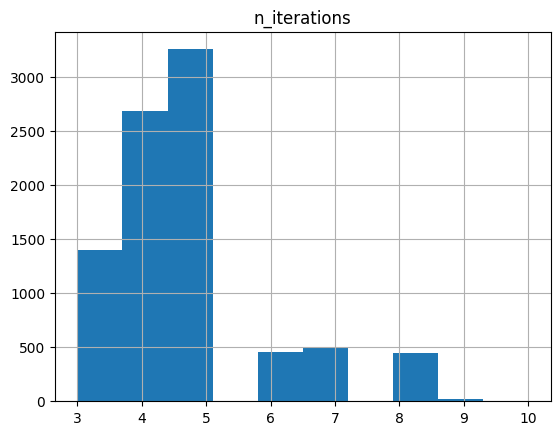

In [3]:
df = pro.simulation_dataframe()
no_converged = df[~df["converged"]]
df.hist("n_iterations")
#no_converged

In [4]:
T_esp = pro.component("spaces_1").variable("temperature")
Q_esp = pro.component("spaces_1").variable("system_sensible_heat")
Q_esplat = pro.component("spaces_1").variable("system_latent_heat")
Q_sys = pro.component("system").variable("Q_sensible")
Q_syslat = pro.component("system").variable("Q_latent")

sim.plot(pro.dates(),[T_esp],axis=[1,2])

In [5]:
sim.plot(pro.dates(),[Q_esp, Q_sys])

In [6]:
sim.plot(pro.dates(),[Q_esplat, Q_syslat])

In [7]:
T_wgo = pro.component("water_system").variable("T_WGO")
f_load = pro.component("water_system").variable("generator_part_load")

In [8]:
sim.plot(pro.dates(),[f_load,T_wgo],axis=[1,2])

In [22]:
from datetime import datetime
target = datetime(2001, 1, 1, 10
                  , 30, 0)
idx = list(pro.dates()).index(target)
idx

10